In [1]:
# Registration Number: 202454206017
# AI & ML Lab Assignment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV, RidgeCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from xgboost import XGBRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.manifold import TSNE
import umap.umap_ as umap


In [2]:
#Loading Datasets
credit = pd.read_csv("Credit.csv")
iris = pd.read_csv("Iris.csv")

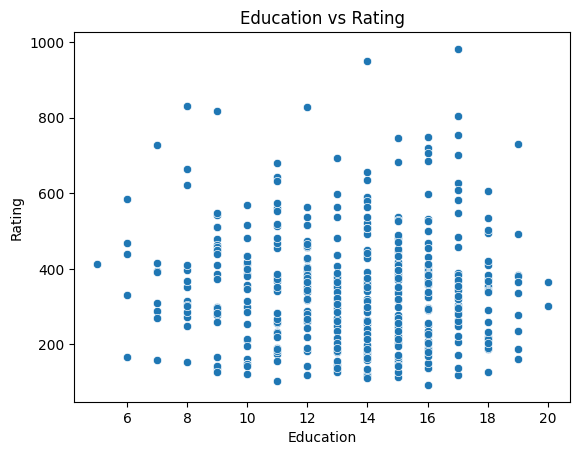

                            OLS Regression Results                            
Dep. Variable:                 Rating   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.3549
Date:                Sun, 04 Jan 2026   Prob (F-statistic):              0.552
Time:                        19:14:16   Log-Likelihood:                -2078.9
No. Observations:                 320   AIC:                             4162.
Df Residuals:                     318   BIC:                             4169.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        377.2758     39.448      9.564      0.0

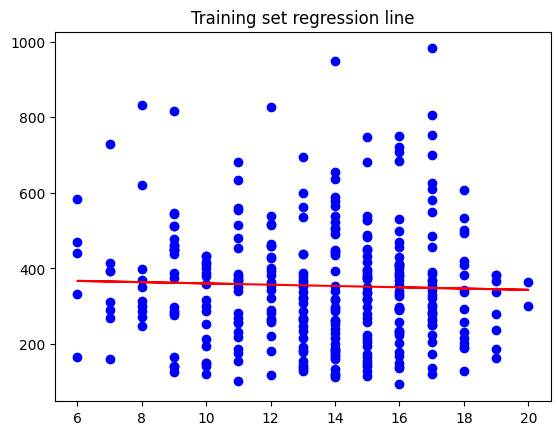

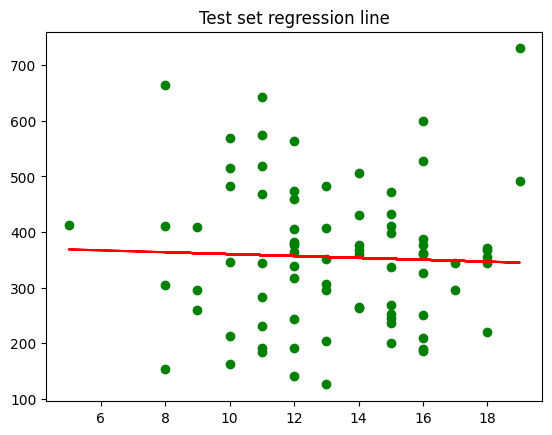

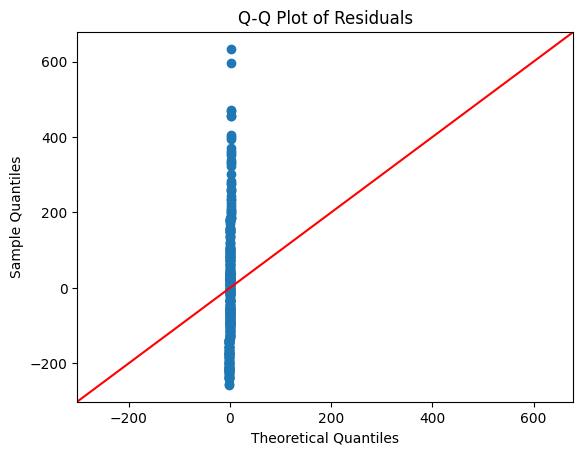

In [3]:
# Question 01: Simple Linear Regression (Education → Rating)
X = credit[['Education']]
Y = credit['Rating']

sns.scatterplot(x=X['Education'], y=Y)
plt.title("Education vs Rating")
plt.show()

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, Y_train)

X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(Y_train, X_train_sm).fit()
print(ols_model.summary())

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

mse = mean_squared_error(Y_test, test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, test_pred)
print(f"Q1 Metrics -> MSE: {mse}, RMSE: {rmse}, MAE: {mae}")

plt.scatter(X_train, Y_train, color='blue')
plt.plot(X_train, train_pred, color='red')
plt.title("Training set regression line")
plt.show()

plt.scatter(X_test, Y_test, color='green')
plt.plot(X_test, test_pred, color='red')
plt.title("Test set regression line")
plt.show()

residuals = Y_train - train_pred
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

In [4]:
# Question 02: Classification (Own Prediction)

credit['Own'] = LabelEncoder().fit_transform(credit['Own'])
X = credit[['Rating','Student','Age','Married','Limit']]
X = pd.get_dummies(X, drop_first=True)
Y = credit['Own']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

results = []
for name, clf in models.items():
    clf.fit(X_train, Y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred)
    rec = recall_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)
    mae = mean_absolute_error(Y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
    results.append([name, acc, prec, rec, f1, mae, rmse])
    print(f"{name} Confusion Matrix:\n{confusion_matrix(Y_test, y_pred)}")

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1","MAE","RMSE"])
print("Q2 Results:\n", results_df)


Logistic Regression Confusion Matrix:
[[10 26]
 [20 24]]
Decision Tree Confusion Matrix:
[[16 20]
 [18 26]]
Random Forest Confusion Matrix:
[[22 14]
 [19 25]]
KNN Confusion Matrix:
[[16 20]
 [20 24]]
SVM Confusion Matrix:
[[20 16]
 [29 15]]
Q2 Results:
                  Model  Accuracy  Precision    Recall        F1     MAE  \
0  Logistic Regression    0.4250   0.480000  0.545455  0.510638  0.5750   
1        Decision Tree    0.5250   0.565217  0.590909  0.577778  0.4750   
2        Random Forest    0.5875   0.641026  0.568182  0.602410  0.4125   
3                  KNN    0.5000   0.545455  0.545455  0.545455  0.5000   
4                  SVM    0.4375   0.483871  0.340909  0.400000  0.5625   

       RMSE  
0  0.758288  
1  0.689202  
2  0.642262  
3  0.707107  
4  0.750000  


In [5]:
# Question 03: Regression (Rating Prediction)

X = credit[['Income','Limit','Age','Own','Student','Married']]
X = pd.get_dummies(X, drop_first=True)
Y = credit['Rating']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

regressors = {
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVM": SVR(),
    "GradientBoost": GradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "XGBoost": XGBRegressor()
}

results = []
for name, reg in regressors.items():
    reg.fit(X_train, Y_train)
    y_pred = reg.predict(X_test)
    mse = mean_squared_error(Y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_test, y_pred)
    r2 = reg.score(X_test, Y_test)
    results.append([name, mse, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=["Model","MSE","RMSE","MAE","R2"])
print("Q3 Results:\n", results_df)

lasso = LassoCV(cv=5).fit(X_train, Y_train)
ridge = RidgeCV(cv=5).fit(X_train, Y_train)

print("Lasso alpha:", lasso.alpha_, "MSE:", mean_squared_error(Y_test, lasso.predict(X_test)), "R2:", lasso.score(X_test, Y_test))
print("Ridge alpha:", ridge.alpha_, "MSE:", mean_squared_error(Y_test, ridge.predict(X_test)), "R2:", ridge.score(X_test, Y_test))

lasso_features = pd.Series(lasso.coef_, index=X.columns)
print("Lasso selected features:\n", lasso_features[lasso_features!=0])


Q3 Results:
            Model           MSE        RMSE        MAE        R2
0  Decision Tree    258.262500   16.070548  13.362500  0.984229
1  Random Forest    200.911647   14.174331  11.453750  0.987731
2            KNN   3737.399500   61.134274  39.787500  0.771766
3            SVM  15194.985688  123.267943  96.687173  0.072078
4  GradientBoost    190.430883   13.799670  11.223995  0.988371
5       AdaBoost    192.630886   13.879153  11.318082  0.988236
6        XGBoost    202.174271   14.218800  11.031811  0.987654
Lasso alpha: 0.16793862254966405 MSE: 122.41015211974013 R2: 0.992524700682046
Ridge alpha: 0.1 MSE: 128.2605577328873 R2: 0.9921674302078869
Lasso selected features:
 Income           3.322680
Limit          864.338435
Married_Yes      0.495075
dtype: float64


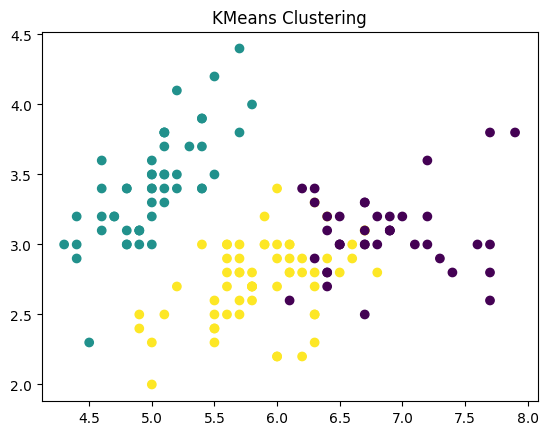

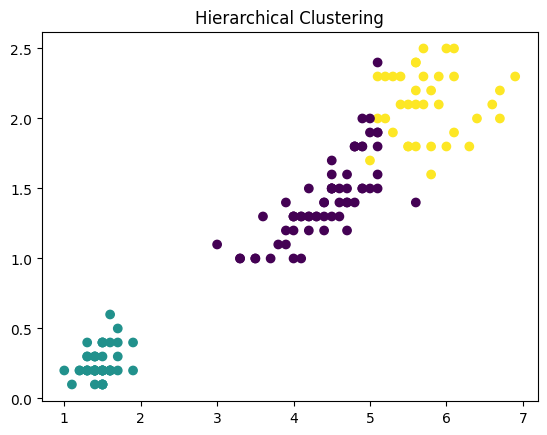

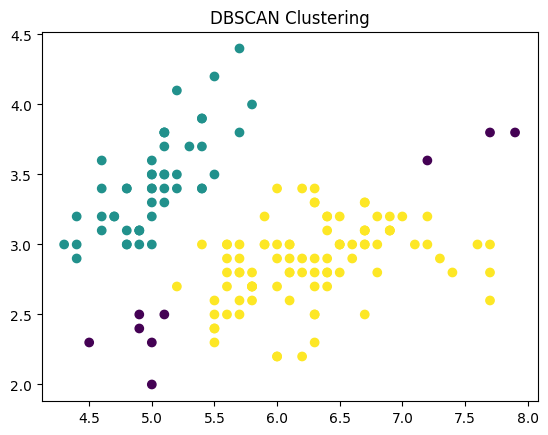

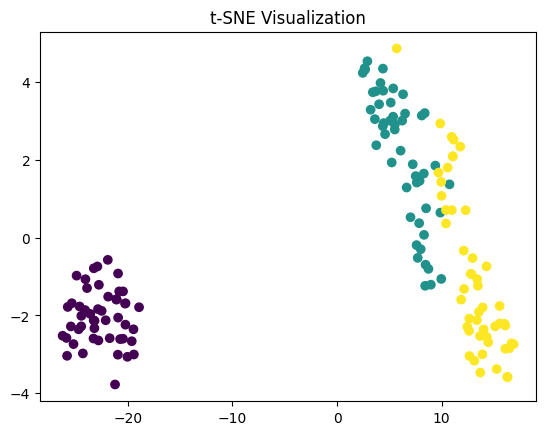

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


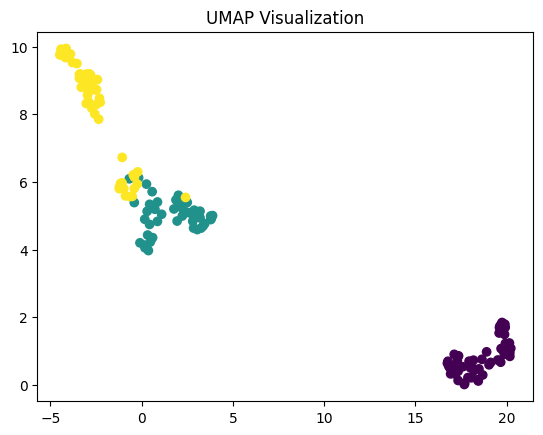

In [6]:
# Question 04: Clustering & Dimensionality Reduction (Iris Data)

X = iris[['Sepal Length','Sepal Width','Petal Length','Petal Width']]
y = iris['Species']

kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
plt.scatter(X['Sepal Length'], X['Sepal Width'], c=kmeans.labels_)
plt.title("KMeans Clustering")
plt.show()

hier = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X)
plt.scatter(X['Petal Length'], X['Petal Width'], c=hier.labels_)
plt.title("Hierarchical Clustering")
plt.show()

dbscan = DBSCAN(eps=0.6, min_samples=5).fit(X)
plt.scatter(X['Sepal Length'], X['Sepal Width'], c=dbscan.labels_)
plt.title("DBSCAN Clustering")
plt.show()

tsne = TSNE(n_components=2, random_state=42).fit_transform(X)
plt.scatter(tsne[:,0], tsne[:,1], c=y.astype('category').cat.codes)
plt.title("t-SNE Visualization")
plt.show()

umap_res = umap.UMAP(n_components=2, random_state=42).fit_transform(X)
plt.scatter(umap_res[:,0], umap_res[:,1], c=y.astype('category').cat.codes)
plt.title("UMAP Visualization")
plt.show()